In [265]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.data_loader import get_team_info
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns



In [266]:
df = pd.read_csv("../data/processed/clean_matches.csv")

df.head()

,match_id,radiant_win,start_time,duration,leagueid,radiant_score,dire_score,radiant_team_id,radiant_team_name,dire_team_id,dire_team_name,series_id,series_type,total_kills,game_speed_categorize
0,8712056091,True,2026-03-01 18:10:52,47.22,19269,32,31,8291895,NaN,9467224,NaN,1069888.0,2.0,63,Late
1,8711970053,True,2026-03-01 17:07:03,31.98,19269,37,8,9467224,NaN,8291895,NaN,1069888.0,2.0,45,Normal
2,8711885801,False,2026-03-01 16:08:54,28.18,19269,6,28,9467224,NaN,8291895,NaN,1069888.0,2.0,34,Fast
3,8711768658,False,2026-03-01 14:54:59,41.80,19269,11,37,9467224,NaN,8291895,NaN,1069888.0,2.0,48,Late
4,8711578057,True,2026-03-01 13:05:55,34.67,19269,30,15,9467224,NaN,2163,NaN,1069815.0,1.0,45,Normal


In [267]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   match_id               933 non-null    int64  
 1   radiant_win            933 non-null    bool   
 2   start_time             933 non-null    object 
 3   duration               933 non-null    float64
 4   leagueid               933 non-null    int64  
 5   radiant_score          933 non-null    int64  
 6   dire_score             933 non-null    int64  
 7   radiant_team_id        933 non-null    int64  
 8   radiant_team_name      0 non-null      float64
 9   dire_team_id           933 non-null    int64  
 10  dire_team_name         0 non-null      float64
 11  series_id              931 non-null    float64
 12  series_type            931 non-null    float64
 13  total_kills            933 non-null    int64  
 14  game_speed_categorize  933 non-null    object 
dtypes: boo

,match_id,duration,leagueid,radiant_score,dire_score,radiant_team_id,radiant_team_name,dire_team_id,dire_team_name,series_id,series_type,total_kills
count,9.330000e+02,933.000000,933.000000,933.000000,933.000000,9.330000e+02,0.0,9.330000e+02,0.0,9.310000e+02,931.000000,933.000000
mean,8.606859e+09,39.987610,18713.996785,23.457663,23.869239,7.658651e+06,NaN,7.382320e+06,NaN,1.046058e+06,1.092374,47.326902
std,6.551143e+07,10.775239,668.500971,10.806212,11.127241,3.186902e+06,NaN,3.406140e+06,NaN,1.490195e+04,0.863885,12.858144
min,8.510884e+09,15.750000,17419.000000,1.000000,1.000000,3.600000e+01,NaN,3.600000e+01,NaN,1.022755e+06,0.000000,14.000000
25%,8.560169e+09,32.500000,18863.000000,15.000000,14.000000,8.254145e+06,NaN,7.119388e+06,NaN,1.035897e+06,1.000000,39.000000
50%,8.600165e+09,38.350000,18988.000000,24.000000,24.000000,9.303484e+06,NaN,9.247354e+06,NaN,1.045547e+06,1.000000,46.000000
75%,8.678990e+09,45.800000,19099.000000,32.000000,32.000000,9.572001e+06,NaN,9.467224e+06,NaN,1.061831e+06,1.000000,55.000000
max,8.712056e+09,85.120000,19269.000000,53.000000,61.000000,9.989747e+06,NaN,9.989756e+06,NaN,1.069888e+06,3.000000,95.000000


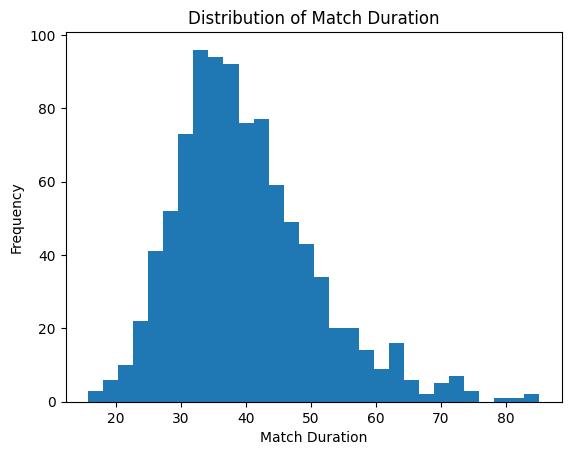

In [268]:
plt.hist(df["duration"], bins=30)
plt.xlabel("Match Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Match Duration")
plt.show()

In [269]:
bins = list(range(30,45))

df["duration_group"] = pd.cut(df["duration"], bins=bins)

df["duration_group"].value_counts().sort_index()

duration_group
(30, 31]    34
(31, 32]    34
(32, 33]    31
(33, 34]    47
(34, 35]    37
(35, 36]    44
(36, 37]    39
(37, 38]    45
(38, 39]    33
(39, 40]    40
(40, 41]    31
(41, 42]    30
(42, 43]    40
(43, 44]    24
Name: count, dtype: int64

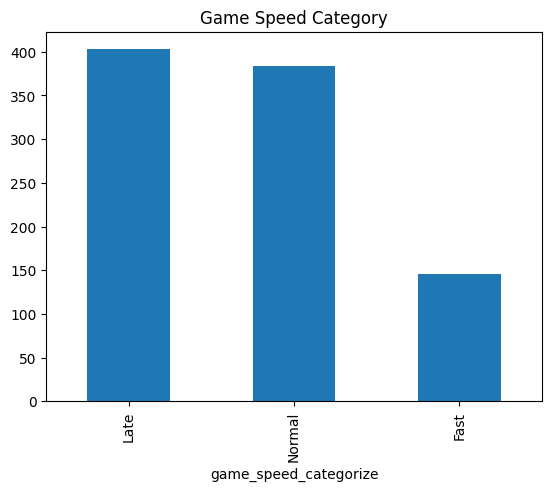

In [270]:
df["game_speed_categorize"].value_counts().plot(kind="bar")
plt.title("Game Speed Category")
plt.show()

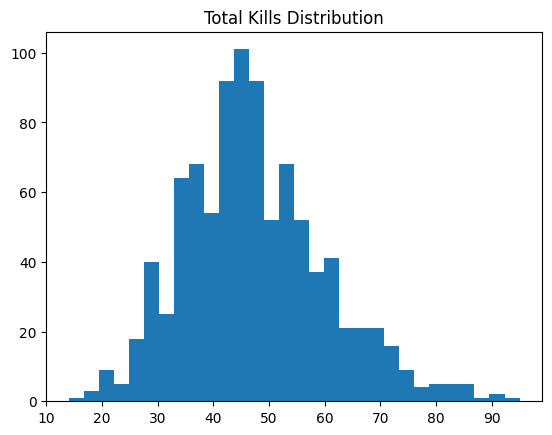

In [271]:
plt.hist(df["total_kills"], bins=30)
plt.title("Total Kills Distribution")
plt.show()

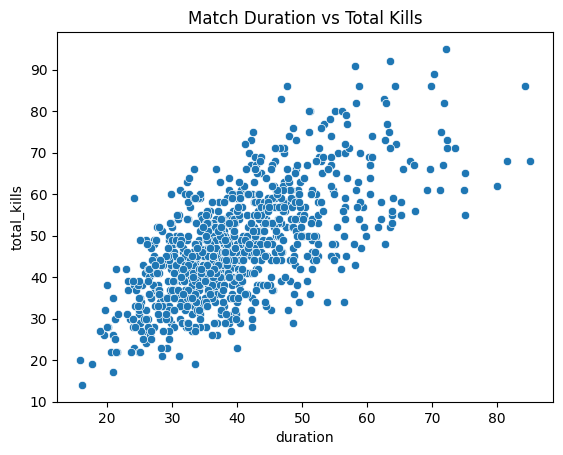

In [272]:
sns.scatterplot(
    data=df,
    x="duration",
    y="total_kills"
)

plt.title("Match Duration vs Total Kills")
plt.show()

In [273]:
df["radiant_win"].value_counts(normalize=True)

radiant_win
False    0.505895
True     0.494105
Name: proportion, dtype: float64

In [274]:
team_df = pd.read_csv("../data/processed/team_mapping.csv")
team_map = dict(zip(team_df.team_id, team_df.team_name))

In [275]:
df["radiant_team_name"] = df["radiant_team_id"].map(team_map)
df["dire_team_name"] = df["dire_team_id"].map(team_map)

In [276]:
radiant = df[[
    "radiant_team_name",
    "radiant_score",
    "duration"
]].copy()

radiant.columns = ["team","kills","duration_match"]

dire = df[[
    "dire_team_name",
    "dire_score",
    "duration"
]].copy()

dire.columns = ["team","kills","duration_match"]

teams_df = pd.concat([radiant, dire])


In [277]:
teams_df = teams_df[~teams_df["team"].isin(["Team Somnus", "Team Quinn"])]
teams_df.groupby("team")["kills"].mean().sort_values(ascending=False).head(10)


team
Tundra Esports    27.007143
Team Liquid       26.985075
Team Falcons      25.926829
Team Spirit       25.560748
HEROIC            25.239583
Team Yandex       24.961905
OG                24.452381
Aurora Gaming     24.318182
PARIVISION        24.206897
Pipsqueak+4       23.428571
Name: kills, dtype: float64

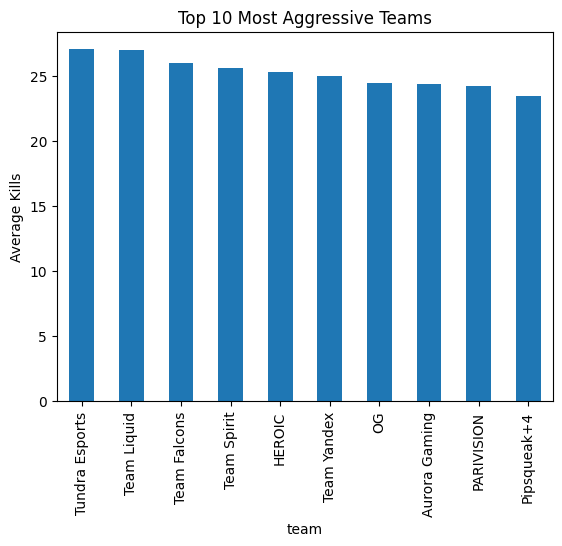

In [278]:
top_kills = teams_df.groupby("team")["kills"].mean().sort_values(ascending=False).head(10)

top_kills.plot(kind="bar")

plt.title("Top 10 Most Aggressive Teams")
plt.ylabel("Average Kills")
plt.show()

In [279]:
radiant = df[[
    "match_id",
    "radiant_team_name",
    "radiant_win",
    "duration",
    "total_kills"
    
]].copy()

radiant.columns = ["match_id", "team_name", "win", "duration", "total_kills"]

dire = df [[
    "match_id",
    "dire_team_name",
    "radiant_win",
    "duration",
    "total_kills"
]].copy()

dire.columns = ["match_id", "team_name", "radiant_win", "duration", "total_kills"]

dire["win"] = ~dire["radiant_win"]
dire = dire[["match_id", "team_name", "win", "duration", "total_kills"]]

teams_result = pd.concat([radiant, dire])

In [280]:
team_matches = teams_df.groupby("team").size().reset_index(name="matches_played")

team_matches = team_matches.sort_values("matches_played", ascending=False)

team_matches

,team,matches_played
7,MOUZ,146
26,Tundra Esports,140
20,Team Liquid,134
19,Team Falcons,123
3,BetBoom Team,111
22,Team Spirit,107
24,Team Yandex,105
29,Xtreme Gaming,101
6,HEROIC,96
8,Natus Vincere,89


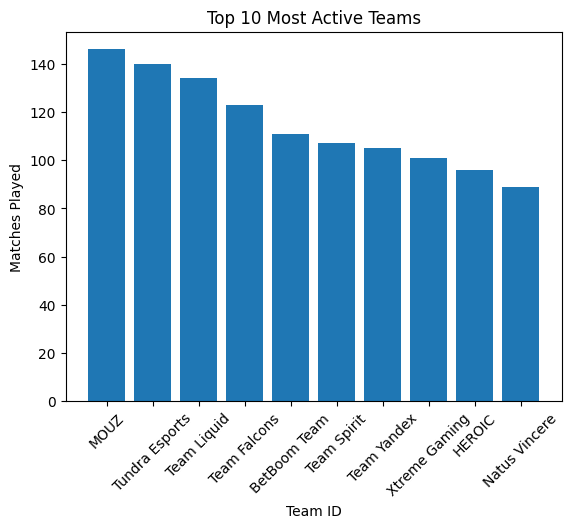

In [281]:
top_teams = team_matches.head(10)

plt.bar(top_teams["team"].astype(str), top_teams["matches_played"])
plt.title("Top 10 Most Active Teams")
plt.xlabel("Team ID")
plt.ylabel("Matches Played")
plt.xticks(rotation=45)
plt.show()

In [282]:
team_wins = teams_result.groupby("team_name")["win"].sum().reset_index()

team_wins = team_wins.sort_values("win", ascending=False)

team_wins.head(10)

,team_name,win
28,Tundra Esports,92
20,Team Liquid,82
7,MOUZ,79
19,Team Falcons,76
24,Team Spirit,62
26,Team Yandex,57
3,BetBoom Team,56
31,Xtreme Gaming,51
11,PARIVISION,49
2,Aurora Gaming,48


In [287]:
wins_only = teams_result[teams_result["win"] == True]
lose_only = teams_result[teams_result["win"] == False]
win_duration = wins_only.groupby("team_name")["duration"].mean().reset_index()
lose_duration = lose_only.groupby("team_name")["duration"].mean().reset_index()
win_duration.columns = ["team_name", "avg_win_duration"]
lose_duration.columns = ["team_name", "avg_lose_duration"]
win_kills = teams_result[teams_result["win"] == True]
lose_kills = teams_result[teams_result["win"] == False]
total_win_kills = win_kills.groupby("team_name")["total_kills"].mean().reset_index()
total_lose_kills = lose_kills.groupby("team_name")["total_kills"].mean().reset_index()
total_win_kills.columns = ["team_name", "avg_kills_win"]
total_lose_kills.columns = ["team_name", "avg_kills_lose"]

team_stats = teams_result[~teams_result["team_name"].isin(["Team Somnus", "Team Quinn"])]
team_stats = team_stats.groupby("team_name").agg(
    total_wins=("win", "sum"),
    total_matches=("win", "count"),
    avg_duration=("duration", "mean"),
    avg_kills=("total_kills", "mean")
).reset_index()


team_stats = team_stats.merge(win_duration, on="team_name", how="left")
team_stats = team_stats.merge(lose_duration, on="team_name", how="left")
team_stats = team_stats.merge(total_win_kills, on="team_name", how="left")
team_stats = team_stats.merge(total_lose_kills, on="team_name", how="left")

team_stats["winrate"] = team_stats["total_wins"] / team_stats["total_matches"]
team_stats.sort_values("winrate", ascending=False).head(15)

,team_name,total_wins,total_matches,avg_duration,avg_kills,avg_win_duration,avg_lose_duration,avg_kills_win,avg_kills_lose,winrate
26,Tundra Esports,92,140,40.091857,49.414286,38.695000,42.769167,48.391304,51.375000,0.657143
19,Team Falcons,76,123,41.621951,47.991870,41.356316,42.051489,47.184211,49.297872,0.617886
20,Team Liquid,82,134,39.899627,49.955224,38.585488,41.971923,48.792683,51.788462,0.611940
22,Team Spirit,62,107,40.273738,47.130841,38.488871,42.732889,46.129032,48.511111,0.579439
11,PARIVISION,49,87,42.245632,46.000000,40.111429,44.997632,44.653061,47.736842,0.563218
2,Aurora Gaming,48,88,40.815909,47.136364,42.336042,38.991750,48.729167,45.225000,0.545455
24,Team Yandex,57,105,40.139524,47.866667,38.868596,41.648750,46.403509,49.604167,0.542857
7,MOUZ,79,146,37.005068,47.513699,35.960506,38.236716,46.721519,48.447761,0.541096
10,OG,45,84,40.431548,45.666667,38.762667,42.357179,46.577778,44.615385,0.535714
8,Natus Vincere,45,89,41.966742,48.269663,42.048889,41.882727,46.888889,49.681818,0.505618


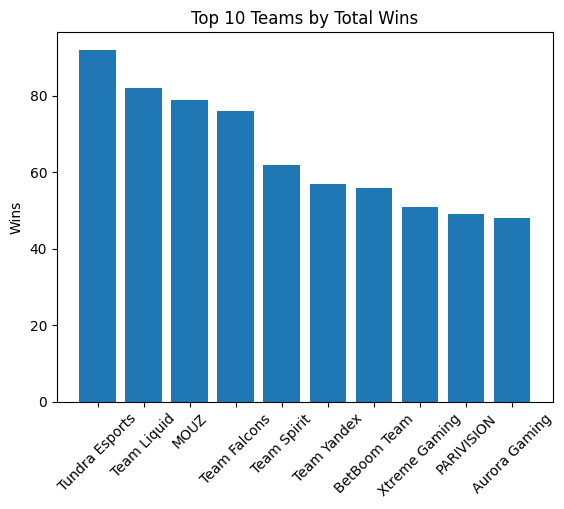

In [284]:
top = team_stats.sort_values("total_wins", ascending=False).head(10)

plt.bar(top["team_name"], top["total_wins"])
plt.xticks(rotation=45)
plt.title("Top 10 Teams by Total Wins")
plt.ylabel("Wins")
plt.show()

In [285]:
df

,match_id,radiant_win,start_time,duration,leagueid,radiant_score,dire_score,radiant_team_id,radiant_team_name,dire_team_id,dire_team_name,series_id,series_type,total_kills,game_speed_categorize,duration_group
0,8712056091,True,2026-03-01 18:10:52,47.22,19269,32,31,8291895,Tundra Esports,9467224,Aurora Gaming,1069888.0,2.0,63,Late,NaN
1,8711970053,True,2026-03-01 17:07:03,31.98,19269,37,8,9467224,Aurora Gaming,8291895,Tundra Esports,1069888.0,2.0,45,Normal,"(31.0, 32.0]"
2,8711885801,False,2026-03-01 16:08:54,28.18,19269,6,28,9467224,Aurora Gaming,8291895,Tundra Esports,1069888.0,2.0,34,Fast,NaN
3,8711768658,False,2026-03-01 14:54:59,41.80,19269,11,37,9467224,Aurora Gaming,8291895,Tundra Esports,1069888.0,2.0,48,Late,"(41.0, 42.0]"
4,8711578057,True,2026-03-01 13:05:55,34.67,19269,30,15,9467224,Aurora Gaming,2163,Team Liquid,1069815.0,1.0,45,Normal,"(34.0, 35.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,8675882674,False,2026-02-03 11:17:05,40.17,19099,18,39,2163,Team Liquid,2586976,OG,1061169.0,0.0,57,Late,"(40.0, 41.0]"
929,8675848583,False,2026-02-03 10:41:00,32.45,19099,6,23,9823272,Team Yandex,9303484,HEROIC,1061166.0,0.0,29,Normal,"(32.0, 33.0]"
930,8675821146,True,2026-02-03 10:09:07,42.37,19099,32,19,7119388,Team Spirit,36,Natus Vincere,1061164.0,0.0,51,Late,"(42.0, 43.0]"
931,8675768384,True,2026-02-03 09:00:34,72.28,19099,37,34,8291895,Tundra Esports,9828897,REKONIX,1061159.0,0.0,71,Late,NaN
